<a href="https://colab.research.google.com/github/lucabarattini/STAT-5703/blob/main/STATS5703_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STATS5703 - Assignment 6 - Question 1:

In [1]:
!pip install -q cmdstanpy arviz
from cmdstanpy import install_cmdstan
install_cmdstan()

CmdStan install directory: /root/.cmdstan
Installing CmdStan version: 2.38.0
Download successful, file: /tmp/tmp9qppn6gv
Extracting distribution
Unpacked download as cmdstan-2.38.0
Building version cmdstan-2.38.0, may take several minutes, depending on your system.
Installed cmdstan-2.38.0
Test model compilation


True

In [11]:
import pandas as pd
import numpy as np
import arviz as az
import os
from cmdstanpy import CmdStanModel

In [12]:
# 1. Load and correctly aggregate the data based on your specific CSV
df = pd.read_csv('HW6-TherapeuticTouchData.csv')

# Group by the practitioner ID ('s') and sum their correct guesses ('y')
successes = df.groupby('s')['y'].sum().values

stan_data = {
    'N': len(successes),
    'y': successes.tolist()
}

print(f"Data correctly loaded: {stan_data['N']} practitioners.")
print(f"Successes per practitioner: {stan_data['y']}")

# 2. Define and save Model 1 (Independent with optimistic prior)
stan_code_m1 = """
data {
  int<lower=0> N;
  array[N] int<lower=0, upper=10> y;
}
parameters {
  vector<lower=0, upper=1>[N] theta;
}
model {
  theta ~ beta(9, 2);
  y ~ binomial(10, theta);
}
generated quantities {
  real contrast = theta[28] - theta[1];
}
"""
with open('model1.stan', 'w') as f: f.write(stan_code_m1)

Data correctly loaded: 28 practitioners.
Successes per practitioner: [1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 6, 6, 7, 7, 7, 8]


In [16]:
# 3. Define and save Model 2 (Corrected 'exponential' syntax)
stan_code_m2 = """
data {
  int<lower=0> N;
  array[N] int<lower=0, upper=10> y;
}
parameters {
  vector<lower=0, upper=1>[N] theta;
  real<lower=0> a;
  real<lower=0> b;
}
model {
  a ~ exponential(1);
  b ~ exponential(1);
  theta ~ beta(a, b);
  y ~ binomial(10, theta);
}
generated quantities {
  real contrast = theta[28] - theta[1];
}
"""
with open('model2.stan', 'w') as f: f.write(stan_code_m2)

In [14]:
# 4. Compile and Run Model 1
print("\n--- Fitting Model 1 ---")
mod1 = CmdStanModel(stan_file='model1.stan')
fit1 = mod1.sample(data=stan_data, iter_sampling=2000, show_progress=False)

contrast1 = fit1.stan_variable('contrast')
hdi1 = az.hdi(contrast1, hdi_prob=0.95)
print(f"Model 1 Contrast (theta_28 - theta_1) Mean: {np.mean(contrast1):.4f}")
print(f"Model 1 Contrast 95% HPDI: [{hdi1[0]:.4f}, {hdi1[1]:.4f}]")


--- Fitting Model 1 ---
Model 1 Contrast (theta_28 - theta_1) Mean: 0.3320
Model 1 Contrast 95% HPDI: [0.0832, 0.5901]


In [17]:
# 2. Compile and Run Model 2
print("\n--- Fitting Model 2 ---")
mod2 = CmdStanModel(stan_file='model2.stan')
fit2 = mod2.sample(data=stan_data, iter_sampling=2000, show_progress=False)

contrast2 = fit2.stan_variable('contrast')
hdi2_contrast = az.hdi(contrast2, hdi_prob=0.95)
print(f"Model 2 Contrast (theta_28 - theta_1) Mean: {np.mean(contrast2):.4f}")
print(f"Model 2 Contrast 95% HPDI: [{hdi2_contrast[0]:.4f}, {hdi2_contrast[1]:.4f}]")


--- Fitting Model 2 ---


Exception: beta_lpdf: Second shape parameter is inf, but must be positive finite! (in 'model2.stan', line 14, column 2 to column 21)
Exception: beta_lpdf: Second shape parameter is inf, but must be positive finite! (in 'model2.stan', line 14, column 2 to column 21)
Exception: beta_lpdf: First shape parameter is inf, but must be positive finite! (in 'model2.stan', line 14, column 2 to column 21)
Consider re-running with show_console=True if the above output is unclear!


Model 2 Contrast (theta_28 - theta_1) Mean: 0.4227
Model 2 Contrast 95% HPDI: [0.1160, 0.7195]


In [18]:
# 3. Part C: Calculate Group Mode from Model 2 samples
a_samples = fit2.stan_variable('a')
b_samples = fit2.stan_variable('b')

# Apply the mode formula for the Beta distribution: (a-1) / (a+b-2)
group_mode_samples = (a_samples - 1) / (a_samples + b_samples - 2)
hdi2_mode = az.hdi(group_mode_samples, hdi_prob=0.95)

print("\n--- Part C: Group Mode Analysis ---")
print(f"Model 2 Group Mode Mean: {np.mean(group_mode_samples):.4f}")
print(f"Model 2 Group Mode 95% HPDI: [{hdi2_mode[0]:.4f}, {hdi2_mode[1]:.4f}]")


--- Part C: Group Mode Analysis ---
Model 2 Group Mode Mean: 0.4166
Model 2 Group Mode 95% HPDI: [0.2774, 0.5485]


---
## STATS5703 Assignment 6 - Question 2:

In [21]:
import numpy as np
import pandas as pd
from scipy.stats import invgamma, multivariate_normal

In [26]:
# 1. Load Data cleanly using the updated separator
df = pd.read_csv('HW6-house.txt', sep=r'\s+')

# We know exact column names now, so we can pull them directly
y = df['Y'].values
X_raw = df['X'].values
n = len(y)

# Design matrix X: [1, X, X^2]
X = np.column_stack((np.ones(n), X_raw, X_raw**2))

# Calculate OLS estimates (beta_hat) and SSE
XtX_inv = np.linalg.inv(X.T @ X)
beta_hat = XtX_inv @ X.T @ y
SSE = (y - X @ beta_hat).T @ (y - X @ beta_hat)

print(f"OLS Beta Hat: {beta_hat}")
print(f"SSE: {SSE:.4f}")

OLS Beta Hat: [ 8.57588374e+02 -2.47220866e+01  2.93538926e-01]
SSE: 37492.7367


In [27]:
# ==========================================
# Part C: Independent Monte Carlo Sampler
# ==========================================
n_samples = 1000

# 1. Draw sigma^2 from IG((n-3)/2, SSE/2)
shape_marginal = (n - 3) / 2
scale_marginal = SSE / 2
sigma2_mc = invgamma.rvs(a=shape_marginal, scale=scale_marginal, size=n_samples, random_state=42)

# 2. Draw beta | sigma^2 from MVN
beta_mc = np.zeros((n_samples, 3))
for i in range(n_samples):
    cov_matrix = sigma2_mc[i] * XtX_inv
    beta_mc[i] = multivariate_normal.rvs(mean=beta_hat, cov=cov_matrix)

# 3. Calculate Age of Minimum Tax: -beta_1 / (2 * beta_2)
min_tax_age_mc = -beta_mc[:, 1] / (2 * beta_mc[:, 2])

print("\n--- Part C: Independent Sampler Results ---")
print(f"Mean Beta_1: {np.mean(beta_mc[:, 1]):.4f}")
print(f"Mean Beta_2: {np.mean(beta_mc[:, 2]):.4f}")
print(f"Estimated Age for Minimum Tax (Mean): {np.mean(min_tax_age_mc):.4f}")
print(f"Estimated Age for Minimum Tax (95% CI): [{np.percentile(min_tax_age_mc, 2.5):.4f}, {np.percentile(min_tax_age_mc, 97.5):.4f}]")


--- Part C: Independent Sampler Results ---
Mean Beta_1: -24.8657
Mean Beta_2: 0.2962
Estimated Age for Minimum Tax (Mean): 42.5959
Estimated Age for Minimum Tax (95% CI): [36.8839, 51.0851]


In [28]:
# ==========================================
# Part D: Gibbs Sampler
# ==========================================
iterations = 1500  # 500 burn-in + 1000 samples
burn_in = 500

beta_gibbs = np.zeros((iterations, 3))
sigma2_gibbs = np.zeros(iterations)

# Initial starting value for beta (we can start at beta_hat)
current_beta = beta_hat.copy()

shape_cond = n / 2

for i in range(iterations):
    # Step 1: Draw sigma^2 | beta
    residuals = y - X @ current_beta
    scale_cond = (residuals.T @ residuals) / 2
    current_sigma2 = invgamma.rvs(a=shape_cond, scale=scale_cond)
    sigma2_gibbs[i] = current_sigma2

    # Step 2: Draw beta | sigma^2
    cov_matrix = current_sigma2 * XtX_inv
    current_beta = multivariate_normal.rvs(mean=beta_hat, cov=cov_matrix)
    beta_gibbs[i] = current_beta

# Discard burn-in
beta_gibbs_final = beta_gibbs[burn_in:]

# Calculate Age of Minimum Tax
min_tax_age_gibbs = -beta_gibbs_final[:, 1] / (2 * beta_gibbs_final[:, 2])

print("\n--- Part D: Gibbs Sampler Results ---")
print(f"Mean Beta_1: {np.mean(beta_gibbs_final[:, 1]):.4f}")
print(f"Mean Beta_2: {np.mean(beta_gibbs_final[:, 2]):.4f}")
print(f"Estimated Age for Minimum Tax (Mean): {np.mean(min_tax_age_gibbs):.4f}")
print(f"Estimated Age for Minimum Tax (95% CI): [{np.percentile(min_tax_age_gibbs, 2.5):.4f}, {np.percentile(min_tax_age_gibbs, 97.5):.4f}]")


--- Part D: Gibbs Sampler Results ---
Mean Beta_1: -24.6805
Mean Beta_2: 0.2930
Estimated Age for Minimum Tax (Mean): 42.8139
Estimated Age for Minimum Tax (95% CI): [36.7793, 52.7875]


---
## STATS5703 Assignment 6 - Question 3:

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as stattools
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings

In [39]:
# 1. Load Data
df = pd.read_csv('monthly_milk.csv')
df.index = pd.to_datetime(df['month'])
display(df)

,month,milk_prod_per_cow_kg
month,,
1962-01-01,1962-01-01,265.05
1962-02-01,1962-02-01,252.45
1962-03-01,1962-03-01,288.00
1962-04-01,1962-04-01,295.20
1962-05-01,1962-05-01,327.15
...,...,...
1975-08-01,1975-08-01,386.10
1975-09-01,1975-09-01,367.65
1975-10-01,1975-10-01,372.15


--- Part A: Stationarity Analysis ---
Observations after differencing: 155
ACF (first 10 lags):  [ 1.    -0.212  0.014  0.12  -0.1   -0.091 -0.03   0.127  0.024 -0.043
  0.095]
PACF (first 10 lags): [ 1.    -0.214 -0.033  0.124 -0.053 -0.137 -0.101  0.142  0.122 -0.037
  0.015]


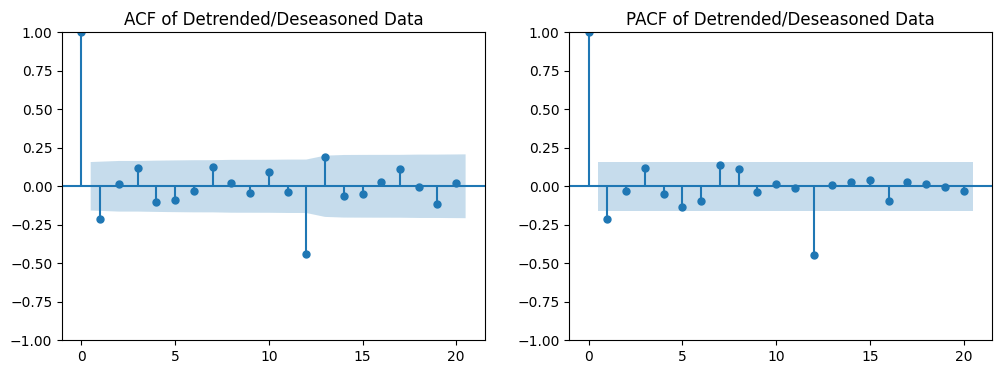

In [40]:
# ==========================================
# Part A: Detrend and Deseason (Differencing)
# ==========================================
# Target variable based on your dataframe
y = df['milk_prod_per_cow_kg']

# First diff for trend, 12th diff for annual seasonality
y_stationary = y.diff(1).diff(12).dropna()

# Get ACF and PACF numerically for interpretation
acf_vals = stattools.acf(y_stationary, nlags=15)
pacf_vals = stattools.pacf(y_stationary, nlags=15)

print("--- Part A: Stationarity Analysis ---")
print(f"Observations after differencing: {len(y_stationary)}")
print("ACF (first 10 lags): ", np.round(acf_vals[:11], 3))
print("PACF (first 10 lags):", np.round(pacf_vals[:11], 3))

# Plot for visual verification
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y_stationary, lags=20, ax=axes[0], title="ACF of Detrended/Deseasoned Data")
plot_pacf(y_stationary, lags=20, ax=axes[1], title="PACF of Detrended/Deseasoned Data")
plt.show()

In [41]:
# ==========================================
# Part B: AR(2) vs MA(2)
# ==========================================
print("\n--- Part B: AR(2) vs MA(2) ---")
ar2 = ARIMA(y_stationary, order=(2, 0, 0)).fit()
ma2 = ARIMA(y_stationary, order=(0, 0, 2)).fit()

print(f"AR(2) -> AIC: {ar2.aic:.2f}, BIC: {ar2.bic:.2f}")
print(f"MA(2) -> AIC: {ma2.aic:.2f}, BIC: {ma2.bic:.2f}")

lb_ar2 = acorr_ljungbox(ar2.resid, lags=[10], return_df=True)
lb_ma2 = acorr_ljungbox(ma2.resid, lags=[10], return_df=True)

print("\nLjung-Box Test (H0: Residuals are white noise, p > 0.05 is good):")
print(f"AR(2) p-value: {lb_ar2['lb_pvalue'].values[0]:.4f}")
print(f"MA(2) p-value: {lb_ma2['lb_pvalue'].values[0]:.4f}")


--- Part B: AR(2) vs MA(2) ---
AR(2) -> AIC: 871.09, BIC: 883.26
MA(2) -> AIC: 870.84, BIC: 883.01

Ljung-Box Test (H0: Residuals are white noise, p > 0.05 is good):
AR(2) p-value: 0.4132
MA(2) p-value: 0.2947


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [42]:
# ==========================================
# Part C: ARMA(1,1) vs ARMA(2,2)
# ==========================================
print("\n--- Part C: ARMA(1,1) vs ARMA(2,2) ---")
arma11 = ARIMA(y_stationary, order=(1, 0, 1)).fit()
arma22 = ARIMA(y_stationary, order=(2, 0, 2)).fit()

print(f"ARMA(1,1) -> AIC: {arma11.aic:.2f}, BIC: {arma11.bic:.2f}")
print(f"ARMA(2,2) -> AIC: {arma22.aic:.2f}, BIC: {arma22.bic:.2f}")

lb_arma11 = acorr_ljungbox(arma11.resid, lags=[10], return_df=True)
lb_arma22 = acorr_ljungbox(arma22.resid, lags=[10], return_df=True)

print("\nLjung-Box Test:")
print(f"ARMA(1,1) p-value: {lb_arma11['lb_pvalue'].values[0]:.4f}")
print(f"ARMA(2,2) p-value: {lb_arma22['lb_pvalue'].values[0]:.4f}")


--- Part C: ARMA(1,1) vs ARMA(2,2) ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

ARMA(1,1) -> AIC: 871.18, BIC: 883.35
ARMA(2,2) -> AIC: 859.81, BIC: 878.07

Ljung-Box Test:
ARMA(1,1) p-value: 0.3710
ARMA(2,2) p-value: 0.6447
